In [2]:
import numpy as np
import pandas as pd

In [3]:
loan_data_inputs_train = pd.read_csv('loan_data_inputs_train.csv')
loan_data_targets_train = pd.read_csv('loan_data_targets_train.csv')
loan_data_inputs_test = pd.read_csv('loan_data_inputs_test.csv')
loan_data_targets_test = pd.read_csv('loan_data_targets_test.csv')

In [4]:
loan_data_inputs_train.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,427211,12796369,14818505,24000,24000,24000.0,36 months,8.90,762.08,A,...,1,0,0,1,0,0,0,0,0,0
1,206088,1439740,1691948,10000,10000,10000.0,36 months,14.33,343.39,C,...,0,0,0,1,0,0,0,0,0,0
2,136020,5214749,6556909,20425,20425,20425.0,36 months,8.90,648.56,A,...,0,0,0,1,0,0,0,0,0,0
3,412305,13827698,15890016,17200,17200,17200.0,36 months,16.59,609.73,D,...,0,0,0,1,0,0,0,0,0,0
4,36159,422455,496525,8400,8400,7450.0,36 months,12.84,282.40,C,...,0,1,0,1,0,0,0,0,0,0


In [5]:
loan_data_targets_train.head()

,good_bad
0,1
1,1
2,1
3,0
4,0


In [6]:
loan_data_inputs_train.shape

(373028, 324)

In [7]:
loan_data_targets_train.shape

(373028, 1)

In [8]:
loan_data_inputs_test.shape

(93257, 324)

In [9]:
loan_data_targets_test.shape

(93257, 1)

In [10]:
inputs_train_with_ref_cat = loan_data_inputs_train.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:mortgage_other_none_any',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'month_since_issue_d:<38',
'month_since_issue_d:38-39',
'month_since_issue_d:40-41',
'month_since_issue_d:42-48',
'month_since_issue_d:49-52',
'month_since_issue_d:53-64',
'month_since_issue_d:65-84',
'month_since_issue_d:>85',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'month_since_earliest_cr_line:<140',
'month_since_earliest_cr_line:141-164',
'month_since_earliest_cr_line:165-247',
'month_since_earliest_cr_line:248-270',
'month_since_earliest_cr_line:271-352',
'month_since_earliest_cr_line:>352',
'delinq_2yrs:0',
'delinq_2yrs:1-3',
'delinq_2yrs:>=4',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'open_acc:0',
'open_acc:1-3',
'open_acc:4-12',
'open_acc:13-17',
'open_acc:18-22',
'open_acc:23-25',
'open_acc:26-30',
'open_acc:>=31',
'pub_rec:0-2',
'pub_rec:3-4',
'pub_rec:>=5',
'total_acc:<=27',
'total_acc:28-51',
'total_acc:>=52',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'total_rev_hi_lim:<=5K',
'total_rev_hi_lim:5K-10K',
'total_rev_hi_lim:10K-20K',
'total_rev_hi_lim:20K-30K',
'total_rev_hi_lim:30K-40K',
'total_rev_hi_lim:40K-55K',
'total_rev_hi_lim:55K-95K',
'total_rev_hi_lim:>95K',
 'annual_inc:<20k',
 'annual_inc:20k-30k',
 'annual_inc:30k-40k',
 'annual_inc:40k-50k',
 'annual_inc:50k-60k',
 'annual_inc:60k-70k',
 'annual_inc:70k-80k',
 'annual_inc:80k-90k',
 'annual_inc:90k-100k',
 'annual_inc:100k-120k',
 'annual_inc:120k-140k',
 'annual_inc:>140k',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>=86']]

In [11]:
print('emp_length:0' in loan_data_inputs_train.columns)

True


In [12]:
missing_in_test=[col for col in loan_data_inputs_train.columns
                 if col not in loan_data_inputs_test.columns]
print(f"Missing columns in test:{len(missing_in_test)}")
print(missing_in_test)

Missing columns in test:0
[]


In [13]:
missing_cols = sorted(
    set(loan_data_inputs_train.columns) -
    set(loan_data_inputs_test.columns)
)

print("Missing columns:", len(missing_cols))
for col in missing_cols:
    print(col)

Missing columns: 0


In [14]:
extra_cols = sorted(
    set(loan_data_inputs_test.columns) -
    set(loan_data_inputs_train.columns)
)

print("Extra columns:", len(extra_cols))
for col in extra_cols:
    print(col)

Extra columns: 0


In [15]:
ref_categories = ['grade:G',
'home_ownership:mortgage_other_none_any',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'month_since_issue_d:>85',
'int_rate:>20.281',
'month_since_earliest_cr_line:<140',
'delinq_2yrs:>=4',
'inq_last_6mths:>6',
'open_acc:0',
'pub_rec:0-2',
'total_acc:<=27',
'acc_now_delinq:0',
'total_rev_hi_lim:<=5K',
'annual_inc:<20k',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [16]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)
inputs_train.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,True,False,False,False,False,False,False,True,False,False,...,1,0,0,0,1,0,0,0,0,0
1,False,False,True,False,False,False,False,True,False,False,...,0,1,0,0,1,0,0,0,0,0
2,True,False,False,False,False,False,False,True,False,False,...,0,0,1,0,1,0,0,0,0,0
3,False,False,False,True,False,False,False,False,False,False,...,0,1,0,0,1,0,0,0,0,0
4,False,False,True,False,False,False,False,True,False,False,...,1,0,0,0,1,0,0,0,0,0


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [18]:
reg = LogisticRegression()

In [19]:
pd.options.display.max_rows = None

In [20]:
reg.fit(inputs_train, loan_data_targets_train)

C:\Users\aswin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
reg.intercept_

array([-0.12968271])

In [22]:
reg.coef_

array([[ 0.43116008,  0.55866506,  0.50103194,  0.42396846,  0.28978729,
         0.10849246,  0.11447462,  0.11483329,  0.03403477,  0.06392359,
         0.08730532,  0.0685897 ,  0.09125857,  0.15725198,  0.12056716,
         0.1974204 ,  0.26036398,  0.25115031,  0.27620384,  0.36547454,
         0.52108039,  0.12704895,  0.10366808,  0.369744  ,  0.27146862,
         0.26304547,  0.31518859,  0.25869488,  0.09114129,  0.02962058,
         0.05427914,  0.0124162 ,  0.02162314,  0.08414423,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -0.37528753,  1.46836092,  0.7984517 ,  0.47331843,  0.13871028,
         0.00161928, -0.0654419 , -0.07691803, -0.02322108, -0.02000125,
        -0.18127473, -0.17342232,  0.44008339,  0.26492687,  0.01624184,
         0.04387729, -0.00725996, -0.05093903, -0.0548727 , -0.05057685,
         0.04779131,  0.01086991,  0.17819642,  0.10984974, -0.0246135 ,
         0.02378098,  0.27186485,  0.13959065,  0.1

In [23]:
feature_name = inputs_train.columns.values

In [24]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.129683
1,grade:A,0.431160
2,grade:B,0.558665
3,grade:C,0.501032
4,grade:D,0.423968
5,grade:E,0.289787
6,grade:F,0.108492
7,home_ownership:OWN,0.114475
8,home_ownership:MORTGAGE,0.114833
9,addr_state:NM_VA,0.034035


In [25]:
from sklearn import linear_model
import scipy.stats as stat


In [26]:
class LogisticRegression_with_p_values:
    def __init__(self,*args,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs)
        
    def fit(self,X,y):
        self.model.fit(X,y)
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X)
        Cramer_Rao = np.linalg.pinv(F_ij)
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores]
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values
            
        
        


In [27]:
inputs_train=inputs_train.astype(float)

In [28]:
reg = LogisticRegression_with_p_values()

In [29]:
reg.fit(inputs_train, loan_data_targets_train)

C:\Users\aswin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\aswin\AppData\Local\Temp\ipykernel_28852\1736942652.py:11: RuntimeWarning: invalid value encountered in sqrt
  sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))


In [30]:
print(inputs_train.shape)
print(type(inputs_train))

(373028, 104)
<class 'pandas.core.frame.DataFrame'>


In [31]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.129683
1,grade:A,0.431160
2,grade:B,0.558665
3,grade:C,0.501032
4,grade:D,0.423968
5,grade:E,0.289787
6,grade:F,0.108492
7,home_ownership:OWN,0.114475
8,home_ownership:MORTGAGE,0.114833
9,addr_state:NM_VA,0.034035


In [32]:
p_values = reg.p_values

In [33]:
p_values = np.append(np.nan, np.array(p_values))

In [34]:
summary_table['p_values'] = p_values

In [35]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.129683,NaN
1,grade:A,0.431160,1.250897e-06
2,grade:B,0.558665,2.791472e-21
3,grade:C,0.501032,1.476591e-19
4,grade:D,0.423968,1.736776e-15
5,grade:E,0.289787,1.698970e-09
6,grade:F,0.108492,3.036214e-02
7,home_ownership:OWN,0.114475,1.221283e-08
8,home_ownership:MORTGAGE,0.114833,8.398449e-20
9,addr_state:NM_VA,0.034035,2.849792e-01


In [36]:
inputs_train_with_ref_cat = loan_data_inputs_train.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:mortgage_other_none_any',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'month_since_issue_d:<38',
'month_since_issue_d:38-39',
'month_since_issue_d:40-41',
'month_since_issue_d:42-48',
'month_since_issue_d:49-52',
'month_since_issue_d:53-64',
'month_since_issue_d:65-84',
'month_since_issue_d:>85',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'month_since_earliest_cr_line:<140',
'month_since_earliest_cr_line:141-164',
'month_since_earliest_cr_line:165-247',
'month_since_earliest_cr_line:248-270',
'month_since_earliest_cr_line:271-352',
'month_since_earliest_cr_line:>352',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'annual_inc:<20k',
 'annual_inc:20k-30k',
 'annual_inc:30k-40k',
 'annual_inc:40k-50k',
 'annual_inc:50k-60k',
 'annual_inc:60k-70k',
 'annual_inc:70k-80k',
 'annual_inc:80k-90k',
 'annual_inc:90k-100k',
 'annual_inc:100k-120k',
 'annual_inc:120k-140k',
 'annual_inc:>140k',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>=86']]

In [37]:
ref_categories = ['grade:G',
'home_ownership:mortgage_other_none_any',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'month_since_issue_d:>85',
'int_rate:>20.281',
'month_since_earliest_cr_line:<140',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'annual_inc:<20k',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [38]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)
inputs_train.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,True,False,False,False,False,False,False,True,False,False,...,1,0,0,0,1,0,0,0,0,0
1,False,False,True,False,False,False,False,True,False,False,...,0,1,0,0,1,0,0,0,0,0
2,True,False,False,False,False,False,False,True,False,False,...,0,0,1,0,1,0,0,0,0,0
3,False,False,False,True,False,False,False,False,False,False,...,0,1,0,0,1,0,0,0,0,0
4,False,False,True,False,False,False,False,True,False,False,...,1,0,0,0,1,0,0,0,0,0


In [39]:
print(inputs_train.dtypes.value_counts())
print(inputs_train.shape)

int64    58
bool     26
Name: count, dtype: int64
(373028, 84)


In [40]:
inputs_train=inputs_train.astype(float)
print(inputs_train.dtypes.value_counts())

float64    84
Name: count, dtype: int64


In [41]:
reg2 = LogisticRegression_with_p_values()
reg2.fit(inputs_train, loan_data_targets_train)

C:\Users\aswin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\aswin\AppData\Local\Temp\ipykernel_28852\1736942652.py:11: RuntimeWarning: invalid value encountered in sqrt
  sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))


In [42]:
feature_name = inputs_train.columns.values

In [43]:
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg2.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.583921
1,grade:A,0.465302
2,grade:B,0.669489
3,grade:C,0.604791
4,grade:D,0.514416
5,grade:E,0.357527
6,grade:F,0.145573
7,home_ownership:OWN,0.132330
8,home_ownership:MORTGAGE,0.123785
9,addr_state:NM_VA,0.010937


In [44]:
p_values = reg2.p_values
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.583921,NaN
1,grade:A,0.465302,2.258183e-07
2,grade:B,0.669489,1.725876e-30
3,grade:C,0.604791,1.849047e-28
4,grade:D,0.514416,9.624894e-23
5,grade:E,0.357527,2.346343e-14
6,grade:F,0.145573,2.751631e-03
7,home_ownership:OWN,0.132330,4.156961e-11
8,home_ownership:MORTGAGE,0.123785,6.058848e-23
9,addr_state:NM_VA,0.010937,7.319132e-01


In [45]:
import pickle

In [46]:
pickle.dump(reg2, open('pd_model.sav', 'wb'))

In [47]:
inputs_test_with_ref_cat = loan_data_inputs_test.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:mortgage_other_none_any',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'month_since_issue_d:<38',
'month_since_issue_d:38-39',
'month_since_issue_d:40-41',
'month_since_issue_d:42-48',
'month_since_issue_d:49-52',
'month_since_issue_d:53-64',
'month_since_issue_d:65-84',
'month_since_issue_d:>85',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'month_since_earliest_cr_line:<140',
'month_since_earliest_cr_line:141-164',
'month_since_earliest_cr_line:165-247',
'month_since_earliest_cr_line:248-270',
'month_since_earliest_cr_line:271-352',
'month_since_earliest_cr_line:>352',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'annual_inc:<20k',
 'annual_inc:20k-30k',
 'annual_inc:30k-40k',
 'annual_inc:40k-50k',
 'annual_inc:50k-60k',
 'annual_inc:60k-70k',
 'annual_inc:70k-80k',
 'annual_inc:80k-90k',
 'annual_inc:90k-100k',
 'annual_inc:100k-120k',
 'annual_inc:120k-140k',
 'annual_inc:>140k',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',  
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>=86']]                                                            

In [48]:
ref_categories = ['grade:G',
'home_ownership:mortgage_other_none_any',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'month_since_issue_d:>85',
'int_rate:>20.281',
'month_since_earliest_cr_line:<140',
'inq_last_6mths:>6',
'acc_now_delinq:0',
'annual_inc:<20k',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [49]:
inputs_test = inputs_test_with_ref_cat.drop(ref_categories, axis = 1)
inputs_test.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,False,False,True,False,False,False,False,True,False,False,...,1,0,0,0,1,0,0,0,0,0
1,False,False,False,False,True,False,False,True,False,False,...,0,0,0,0,1,0,0,0,0,0
2,False,False,True,False,False,False,False,True,False,False,...,0,0,1,0,1,0,0,0,0,0
3,False,False,True,False,False,False,False,True,False,False,...,1,0,0,0,1,0,0,0,0,0
4,True,False,False,False,False,False,False,True,False,False,...,0,0,1,0,1,0,0,0,0,0


In [50]:
y_hat_test = reg2.model.predict(inputs_test)

In [51]:
y_hat_test

array([1, 1, 1, ..., 1, 1, 1], shape=(93257,))

In [52]:
y_hat_test_proba = reg2.model.predict_proba(inputs_test)

In [53]:
y_hat_test_proba

array([[0.11429188, 0.88570812],
       [0.19170484, 0.80829516],
       [0.07330207, 0.92669793],
       ...,
       [0.02859283, 0.97140717],
       [0.04858228, 0.95141772],
       [0.04318685, 0.95681315]], shape=(93257, 2))

In [54]:
y_hat_test_proba[: ][: , 1]

array([0.88570812, 0.80829516, 0.92669793, ..., 0.97140717, 0.95141772,
       0.95681315], shape=(93257,))

In [55]:
y_hat_test_proba = y_hat_test_proba[: ][: , 1]

In [56]:
y_hat_test_proba

array([0.88570812, 0.80829516, 0.92669793, ..., 0.97140717, 0.95141772,
       0.95681315], shape=(93257,))

In [57]:
loan_data_targets_test_temp = loan_data_targets_test

In [58]:
loan_data_targets_test_temp.reset_index(drop = True, inplace = True)

In [59]:
df_actual_predicted_probs = pd.concat([loan_data_targets_test_temp, pd.DataFrame(y_hat_test_proba)], axis = 1)

In [60]:
df_actual_predicted_probs.shape

(93257, 2)

In [61]:
df_actual_predicted_probs.columns = ['loan_data_targets_test', 'y_hat_test_proba']

In [62]:
df_actual_predicted_probs.index = loan_data_inputs_test.index

In [63]:
df_actual_predicted_probs.head()

,loan_data_targets_test,y_hat_test_proba
0,1,0.885708
1,1,0.808295
2,1,0.926698
3,1,0.922070
4,1,0.972882


In [64]:
tr = 0.9
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

In [65]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,7405,2785
1,37446,45621


In [66]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]

Predicted,0,1
Actual,,
0,0.079404,0.029864
1,0.401536,0.489197


In [67]:
(pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]

np.float64(0.5686007484692839)

In [68]:
from sklearn.metrics import roc_curve, roc_auc_score

In [69]:
roc_curve(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])

(array([0.        , 0.        , 0.        , ..., 0.99980373, 1.        ,
        1.        ], shape=(17994,)),
 array([0.00000000e+00, 1.20384750e-05, 6.26000698e-04, ...,
        9.99987962e-01, 9.99987962e-01, 1.00000000e+00], shape=(17994,)),
 array([       inf, 0.99094588, 0.98599267, ..., 0.50304594, 0.48345031,
        0.47120616], shape=(17994,)))

In [70]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['loan_data_targets_test'],
                                 df_actual_predicted_probs['y_hat_test_proba'])

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Text(0.5, 1.0, 'ROC curve')

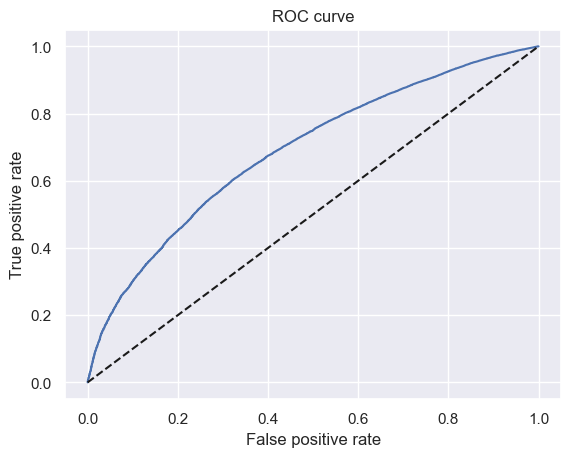

In [72]:
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [73]:
AUROC = roc_auc_score(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])
AUROC

0.6890558472178359

In [74]:
df_actual_predicted_probs = df_actual_predicted_probs.sort_values('y_hat_test_proba')

In [75]:
df_actual_predicted_probs.head()

,loan_data_targets_test,y_hat_test_proba,y_hat_test
14868,1,0.471206,0
85282,0,0.483450,0
48752,0,0.502472,0
81229,1,0.503046,0
58288,1,0.516121,0


In [76]:
df_actual_predicted_probs.tail()

,loan_data_targets_test,y_hat_test_proba,y_hat_test
49559,1,0.989133,1
54837,1,0.990227,1
19567,1,0.990440,1
62389,1,0.990476,1
59452,1,0.990946,1


In [77]:
df_actual_predicted_probs = df_actual_predicted_probs.reset_index()

In [78]:
df_actual_predicted_probs.head()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test
0,14868,1,0.471206,0
1,85282,0,0.483450,0
2,48752,0,0.502472,0
3,81229,1,0.503046,0
4,58288,1,0.516121,0


In [79]:
df_actual_predicted_probs['Cumulative N Population'] = df_actual_predicted_probs.index + 1
df_actual_predicted_probs['Cumulative N Good'] = df_actual_predicted_probs['loan_data_targets_test'].cumsum()
df_actual_predicted_probs['Cumulative N Bad'] = df_actual_predicted_probs['Cumulative N Population'] - df_actual_predicted_probs['loan_data_targets_test'].cumsum()

In [80]:
df_actual_predicted_probs.head()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad
0,14868,1,0.471206,0,1,1,0
1,85282,0,0.483450,0,2,1,1
2,48752,0,0.502472,0,3,1,2
3,81229,1,0.503046,0,4,2,2
4,58288,1,0.516121,0,5,3,2


In [81]:
df_actual_predicted_probs['Cumulative Perc Population'] = df_actual_predicted_probs['Cumulative N Population'] / (df_actual_predicted_probs.shape[0])
df_actual_predicted_probs['Cumulative Perc Good'] = df_actual_predicted_probs['Cumulative N Good'] / df_actual_predicted_probs['loan_data_targets_test'].sum()
df_actual_predicted_probs['Cumulative Perc Bad'] = df_actual_predicted_probs['Cumulative N Bad'] / (df_actual_predicted_probs.shape[0] - df_actual_predicted_probs['loan_data_targets_test'].sum())

In [82]:
df_actual_predicted_probs.head()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
0,14868,1,0.471206,0,1,1,0,0.000011,0.000012,0.000000
1,85282,0,0.483450,0,2,1,1,0.000021,0.000012,0.000098
2,48752,0,0.502472,0,3,1,2,0.000032,0.000012,0.000196
3,81229,1,0.503046,0,4,2,2,0.000043,0.000024,0.000196
4,58288,1,0.516121,0,5,3,2,0.000054,0.000036,0.000196


In [83]:
df_actual_predicted_probs.tail()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
93252,49559,1,0.989133,1,93253,83063,10190,0.999957,0.999952,1.0
93253,54837,1,0.990227,1,93254,83064,10190,0.999968,0.999964,1.0
93254,19567,1,0.990440,1,93255,83065,10190,0.999979,0.999976,1.0
93255,62389,1,0.990476,1,93256,83066,10190,0.999989,0.999988,1.0
93256,59452,1,0.990946,1,93257,83067,10190,1.000000,1.000000,1.0


Text(0.5, 1.0, 'Gini')

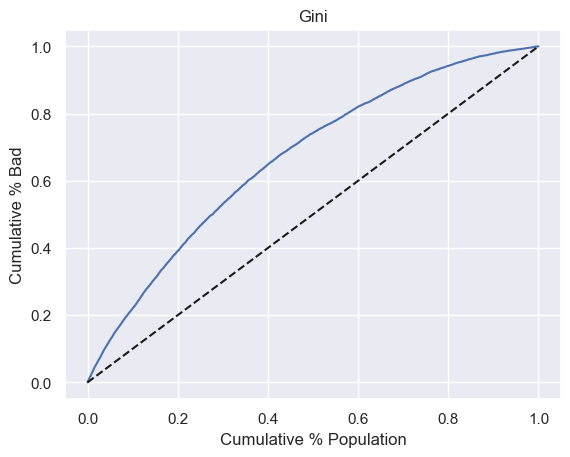

In [84]:
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Bad'])
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Population'], linestyle = '--', color = 'k')
plt.xlabel('Cumulative % Population')
plt.ylabel('Cumulative % Bad')
plt.title('Gini')

In [85]:
Gini = AUROC * 2 - 1
Gini

0.3781116944356717

Text(0.5, 1.0, 'Kolmogorov-Smirnov')

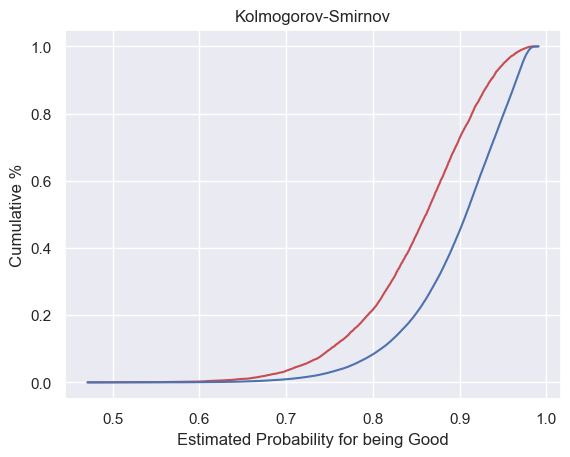

In [86]:
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Bad'], color = 'r')
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Good'], color = 'b')
plt.xlabel('Estimated Probability for being Good')
plt.ylabel('Cumulative %')
plt.title('Kolmogorov-Smirnov')

In [87]:
KS = max(df_actual_predicted_probs['Cumulative Perc Bad'] - df_actual_predicted_probs['Cumulative Perc Good'])
KS

0.2808478342316883

In [88]:
pd.options.display.max_columns = None

In [89]:
inputs_test_with_ref_cat.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:mortgage_other_none_any,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:ND_NE_IA_NV_FL_HI_AL,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:educ__sm_b__wedd__ren_en__mov__house,purpose:credit_card,purpose:debt_consolidation,purpose:oth__med__vacation,purpose:major_purch__car__home_impr,initial_list_status:f,initial_list_status:w,term:36,term:60,emp_length:0,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,month_since_issue_d:<38,month_since_issue_d:38-39,month_since_issue_d:40-41,month_since_issue_d:42-48,month_since_issue_d:49-52,month_since_issue_d:53-64,month_since_issue_d:65-84,month_since_issue_d:>85,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,month_since_earliest_cr_line:<140,month_since_earliest_cr_line:141-164,month_since_earliest_cr_line:165-247,month_since_earliest_cr_line:248-270,month_since_earliest_cr_line:271-352,month_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,inq_last_6mths:>6,acc_now_delinq:0,acc_now_delinq:>=1,annual_inc:<20k,annual_inc:20k-30k,annual_inc:30k-40k,annual_inc:40k-50k,annual_inc:50k-60k,annual_inc:60k-70k,annual_inc:70k-80k,annual_inc:80k-90k,annual_inc:90k-100k,annual_inc:100k-120k,annual_inc:120k-140k,annual_inc:>140k,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_delinq:Missing,mths_since_last_delinq:0-3,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,0,False,False,0,1,True,False,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,0,True,False,0,0,False,True,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
2,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,0,False,True,0,0,True,False,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
3,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,0,False,True,0,0,False,True,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
4,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,0,False,True,0,0,True,False,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0


In [90]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.583921,NaN
1,grade:A,0.465302,2.258183e-07
2,grade:B,0.669489,1.725876e-30
3,grade:C,0.604791,1.849047e-28
4,grade:D,0.514416,9.624894e-23
5,grade:E,0.357527,2.346343e-14
6,grade:F,0.145573,2.751631e-03
7,home_ownership:OWN,0.132330,4.156961e-11
8,home_ownership:MORTGAGE,0.123785,6.058848e-23
9,addr_state:NM_VA,0.010937,7.319132e-01


In [91]:
y_hat_test_proba

array([0.88570812, 0.80829516, 0.92669793, ..., 0.97140717, 0.95141772,
       0.95681315], shape=(93257,))

In [92]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.583921,NaN
1,grade:A,0.465302,2.258183e-07
2,grade:B,0.669489,1.725876e-30
3,grade:C,0.604791,1.849047e-28
4,grade:D,0.514416,9.624894e-23
5,grade:E,0.357527,2.346343e-14
6,grade:F,0.145573,2.751631e-03
7,home_ownership:OWN,0.132330,4.156961e-11
8,home_ownership:MORTGAGE,0.123785,6.058848e-23
9,addr_state:NM_VA,0.010937,7.319132e-01


In [93]:
ref_categories

['grade:G',
 'home_ownership:mortgage_other_none_any',
 'addr_state:ND_NE_IA_NV_FL_HI_AL',
 'verification_status:Verified',
 'purpose:educ__sm_b__wedd__ren_en__mov__house',
 'initial_list_status:f',
 'term:60',
 'emp_length:0',
 'month_since_issue_d:>85',
 'int_rate:>20.281',
 'month_since_earliest_cr_line:<140',
 'inq_last_6mths:>6',
 'acc_now_delinq:0',
 'annual_inc:<20k',
 'dti:>35',
 'mths_since_last_delinq:0-3',
 'mths_since_last_record:0-2']

In [94]:
df_ref_categories = pd.DataFrame(ref_categories, columns = ['Feature name'])
df_ref_categories['Coefficients'] = 0
df_ref_categories['p_values'] = np.nan
df_ref_categories

,Feature name,Coefficients,p_values
0,grade:G,0,NaN
1,home_ownership:mortgage_other_none_any,0,NaN
2,addr_state:ND_NE_IA_NV_FL_HI_AL,0,NaN
3,verification_status:Verified,0,NaN
4,purpose:educ__sm_b__wedd__ren_en__mov__house,0,NaN
5,initial_list_status:f,0,NaN
6,term:60,0,NaN
7,emp_length:0,0,NaN
8,month_since_issue_d:>85,0,NaN
9,int_rate:>20.281,0,NaN


In [95]:
df_scorecard = pd.concat([summary_table, df_ref_categories])
df_scorecard = df_scorecard.reset_index()
df_scorecard

,index,Feature name,Coefficients,p_values
0,0,Intercept,-0.583921,NaN
1,1,grade:A,0.465302,2.258183e-07
2,2,grade:B,0.669489,1.725876e-30
3,3,grade:C,0.604791,1.849047e-28
4,4,grade:D,0.514416,9.624894e-23
5,5,grade:E,0.357527,2.346343e-14
6,6,grade:F,0.145573,2.751631e-03
7,7,home_ownership:OWN,0.132330,4.156961e-11
8,8,home_ownership:MORTGAGE,0.123785,6.058848e-23
9,9,addr_state:NM_VA,0.010937,7.319132e-01


In [96]:
df_scorecard['Original feature name'] = df_scorecard['Feature name'].str.split(':').str[0]

In [97]:
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name
0,0,Intercept,-0.583921,NaN,Intercept
1,1,grade:A,0.465302,2.258183e-07,grade
2,2,grade:B,0.669489,1.725876e-30,grade
3,3,grade:C,0.604791,1.849047e-28,grade
4,4,grade:D,0.514416,9.624894e-23,grade
5,5,grade:E,0.357527,2.346343e-14,grade
6,6,grade:F,0.145573,2.751631e-03,grade
7,7,home_ownership:OWN,0.132330,4.156961e-11,home_ownership
8,8,home_ownership:MORTGAGE,0.123785,6.058848e-23,home_ownership
9,9,addr_state:NM_VA,0.010937,7.319132e-01,addr_state


In [98]:
min_score = 300
max_score = 850

In [99]:
df_scorecard.groupby('Original feature name')['Coefficients'].min()

Original feature name
Intercept                      -0.583921
acc_now_delinq                  0.000000
addr_state                      0.000000
annual_inc                     -0.071134
dti                            -0.330694
emp_length                      0.000000
grade                           0.000000
home_ownership                  0.000000
initial_list_status             0.000000
inq_last_6mths                  0.000000
int_rate                        0.000000
month_since_earliest_cr_line   -0.087893
month_since_issue_d            -0.420586
mths_since_last_delinq          0.000000
mths_since_last_record          0.000000
purpose                         0.000000
term                            0.000000
verification_status             0.000000
Name: Coefficients, dtype: float64

In [100]:
min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()
min_sum_coef

np.float64(-1.4942283612650873)

In [101]:
df_scorecard.groupby('Original feature name')['Coefficients'].max()

Original feature name
Intercept                      -0.583921
acc_now_delinq                  0.366446
addr_state                      0.503045
annual_inc                      0.619776
dti                             0.000000
emp_length                      0.095928
grade                           0.669489
home_ownership                  0.132330
initial_list_status             0.275761
inq_last_6mths                  0.584224
int_rate                        1.527671
month_since_earliest_cr_line    0.000000
month_since_issue_d             0.000000
mths_since_last_delinq          0.286506
mths_since_last_record          0.686572
purpose                         0.405546
term                            0.070235
verification_status             0.104900
Name: Coefficients, dtype: float64

In [102]:
max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()
max_sum_coef

np.float64(5.744508388957275)

In [104]:
df_scorecard['Score - Calculation'] = df_scorecard['Coefficients'] * (max_score - min_score) / (max_sum_coef - min_sum_coef)
df_scorecard


,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-0.583921,NaN,Intercept,-44.366377
1,1,grade:A,0.465302,2.258183e-07,grade,35.353707
2,2,grade:B,0.669489,1.725876e-30,grade,50.867812
3,3,grade:C,0.604791,1.849047e-28,grade,45.952120
4,4,grade:D,0.514416,9.624894e-23,grade,39.085385
5,5,grade:E,0.357527,2.346343e-14,grade,27.164976
6,6,grade:F,0.145573,2.751631e-03,grade,11.060657
7,7,home_ownership:OWN,0.132330,4.156961e-11,home_ownership,10.054452
8,8,home_ownership:MORTGAGE,0.123785,6.058848e-23,home_ownership,9.405161
9,9,addr_state:NM_VA,0.010937,7.319132e-01,addr_state,0.831007


In [105]:
df_scorecard['Score - Calculation'][0] = ((df_scorecard['Coefficients'][0] - min_sum_coef) / (max_sum_coef - min_sum_coef)) * (max_score - min_score) + min_score
df_scorecard

C:\Users\aswin\AppData\Local\Temp\ipykernel_28852\1263832758.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_scorecard['Score - Calculation'][0] = ((df_scorecard['Coefficients'][0] - min_sum_coef) / (max_sum_coef - min_sum_coef)) * (m

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-0.583921,NaN,Intercept,369.165255
1,1,grade:A,0.465302,2.258183e-07,grade,35.353707
2,2,grade:B,0.669489,1.725876e-30,grade,50.867812
3,3,grade:C,0.604791,1.849047e-28,grade,45.952120
4,4,grade:D,0.514416,9.624894e-23,grade,39.085385
5,5,grade:E,0.357527,2.346343e-14,grade,27.164976
6,6,grade:F,0.145573,2.751631e-03,grade,11.060657
7,7,home_ownership:OWN,0.132330,4.156961e-11,home_ownership,10.054452
8,8,home_ownership:MORTGAGE,0.123785,6.058848e-23,home_ownership,9.405161
9,9,addr_state:NM_VA,0.010937,7.319132e-01,addr_state,0.831007


In [106]:
df_scorecard['Score - Preliminary'] = df_scorecard['Score - Calculation'].round()
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary
0,0,Intercept,-0.583921,NaN,Intercept,369.165255,369.0
1,1,grade:A,0.465302,2.258183e-07,grade,35.353707,35.0
2,2,grade:B,0.669489,1.725876e-30,grade,50.867812,51.0
3,3,grade:C,0.604791,1.849047e-28,grade,45.952120,46.0
4,4,grade:D,0.514416,9.624894e-23,grade,39.085385,39.0
5,5,grade:E,0.357527,2.346343e-14,grade,27.164976,27.0
6,6,grade:F,0.145573,2.751631e-03,grade,11.060657,11.0
7,7,home_ownership:OWN,0.132330,4.156961e-11,home_ownership,10.054452,10.0
8,8,home_ownership:MORTGAGE,0.123785,6.058848e-23,home_ownership,9.405161,9.0
9,9,addr_state:NM_VA,0.010937,7.319132e-01,addr_state,0.831007,1.0


In [107]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].min().sum()
min_sum_score_prel

np.float64(300.0)

In [108]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].max().sum()
max_sum_score_prel

np.float64(849.0)

In [109]:
df_scorecard['Difference'] = df_scorecard['Score - Preliminary'] - df_scorecard['Score - Calculation']
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference
0,0,Intercept,-0.583921,NaN,Intercept,369.165255,369.0,-0.165255
1,1,grade:A,0.465302,2.258183e-07,grade,35.353707,35.0,-0.353707
2,2,grade:B,0.669489,1.725876e-30,grade,50.867812,51.0,0.132188
3,3,grade:C,0.604791,1.849047e-28,grade,45.952120,46.0,0.047880
4,4,grade:D,0.514416,9.624894e-23,grade,39.085385,39.0,-0.085385
5,5,grade:E,0.357527,2.346343e-14,grade,27.164976,27.0,-0.164976
6,6,grade:F,0.145573,2.751631e-03,grade,11.060657,11.0,-0.060657
7,7,home_ownership:OWN,0.132330,4.156961e-11,home_ownership,10.054452,10.0,-0.054452
8,8,home_ownership:MORTGAGE,0.123785,6.058848e-23,home_ownership,9.405161,9.0,-0.405161
9,9,addr_state:NM_VA,0.010937,7.319132e-01,addr_state,0.831007,1.0,0.168993


In [110]:
df_scorecard['Score - Final'] = df_scorecard['Score - Preliminary']
df_scorecard['Score - Final'][77] = 16
df_scorecard

C:\Users\aswin\AppData\Local\Temp\ipykernel_28852\1528914224.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_scorecard['Score - Final'][77] = 16
C:\Users\aswin\AppData\Local\Temp\ipykernel_28852\1528914224.py:2: SettingWithCopyWarning

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-0.583921,NaN,Intercept,369.165255,369.0,-0.165255,369.0
1,1,grade:A,0.465302,2.258183e-07,grade,35.353707,35.0,-0.353707,35.0
2,2,grade:B,0.669489,1.725876e-30,grade,50.867812,51.0,0.132188,51.0
3,3,grade:C,0.604791,1.849047e-28,grade,45.952120,46.0,0.047880,46.0
4,4,grade:D,0.514416,9.624894e-23,grade,39.085385,39.0,-0.085385,39.0
5,5,grade:E,0.357527,2.346343e-14,grade,27.164976,27.0,-0.164976,27.0
6,6,grade:F,0.145573,2.751631e-03,grade,11.060657,11.0,-0.060657,11.0
7,7,home_ownership:OWN,0.132330,4.156961e-11,home_ownership,10.054452,10.0,-0.054452,10.0
8,8,home_ownership:MORTGAGE,0.123785,6.058848e-23,home_ownership,9.405161,9.0,-0.405161,9.0
9,9,addr_state:NM_VA,0.010937,7.319132e-01,addr_state,0.831007,1.0,0.168993,1.0


In [111]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].min().sum()
min_sum_score_prel

np.float64(300.0)

In [112]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].max().sum()
max_sum_score_prel

np.float64(847.0)

In [113]:
inputs_test_with_ref_cat.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:mortgage_other_none_any,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:ND_NE_IA_NV_FL_HI_AL,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:educ__sm_b__wedd__ren_en__mov__house,purpose:credit_card,purpose:debt_consolidation,purpose:oth__med__vacation,purpose:major_purch__car__home_impr,initial_list_status:f,initial_list_status:w,term:36,term:60,emp_length:0,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,month_since_issue_d:<38,month_since_issue_d:38-39,month_since_issue_d:40-41,month_since_issue_d:42-48,month_since_issue_d:49-52,month_since_issue_d:53-64,month_since_issue_d:65-84,month_since_issue_d:>85,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,month_since_earliest_cr_line:<140,month_since_earliest_cr_line:141-164,month_since_earliest_cr_line:165-247,month_since_earliest_cr_line:248-270,month_since_earliest_cr_line:271-352,month_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,inq_last_6mths:>6,acc_now_delinq:0,acc_now_delinq:>=1,annual_inc:<20k,annual_inc:20k-30k,annual_inc:30k-40k,annual_inc:40k-50k,annual_inc:50k-60k,annual_inc:60k-70k,annual_inc:70k-80k,annual_inc:80k-90k,annual_inc:90k-100k,annual_inc:100k-120k,annual_inc:120k-140k,annual_inc:>140k,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_delinq:Missing,mths_since_last_delinq:0-3,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,0,False,False,0,1,True,False,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,0,True,False,0,0,False,True,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
2,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,0,False,True,0,0,True,False,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
3,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,0,False,True,0,0,False,True,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
4,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,0,False,True,0,0,True,False,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0


In [114]:
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-0.583921,NaN,Intercept,369.165255,369.0,-0.165255,369.0
1,1,grade:A,0.465302,2.258183e-07,grade,35.353707,35.0,-0.353707,35.0
2,2,grade:B,0.669489,1.725876e-30,grade,50.867812,51.0,0.132188,51.0
3,3,grade:C,0.604791,1.849047e-28,grade,45.952120,46.0,0.047880,46.0
4,4,grade:D,0.514416,9.624894e-23,grade,39.085385,39.0,-0.085385,39.0
5,5,grade:E,0.357527,2.346343e-14,grade,27.164976,27.0,-0.164976,27.0
6,6,grade:F,0.145573,2.751631e-03,grade,11.060657,11.0,-0.060657,11.0
7,7,home_ownership:OWN,0.132330,4.156961e-11,home_ownership,10.054452,10.0,-0.054452,10.0
8,8,home_ownership:MORTGAGE,0.123785,6.058848e-23,home_ownership,9.405161,9.0,-0.405161,9.0
9,9,addr_state:NM_VA,0.010937,7.319132e-01,addr_state,0.831007,1.0,0.168993,1.0


In [115]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat

In [116]:
inputs_test_with_ref_cat_w_intercept.insert(0, 'Intercept', 1)

In [117]:
inputs_test_with_ref_cat_w_intercept.head()

,Intercept,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:mortgage_other_none_any,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:ND_NE_IA_NV_FL_HI_AL,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:educ__sm_b__wedd__ren_en__mov__house,purpose:credit_card,purpose:debt_consolidation,purpose:oth__med__vacation,purpose:major_purch__car__home_impr,initial_list_status:f,initial_list_status:w,term:36,term:60,emp_length:0,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,month_since_issue_d:<38,month_since_issue_d:38-39,month_since_issue_d:40-41,month_since_issue_d:42-48,month_since_issue_d:49-52,month_since_issue_d:53-64,month_since_issue_d:65-84,month_since_issue_d:>85,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,month_since_earliest_cr_line:<140,month_since_earliest_cr_line:141-164,month_since_earliest_cr_line:165-247,month_since_earliest_cr_line:248-270,month_since_earliest_cr_line:271-352,month_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,inq_last_6mths:>6,acc_now_delinq:0,acc_now_delinq:>=1,annual_inc:<20k,annual_inc:20k-30k,annual_inc:30k-40k,annual_inc:40k-50k,annual_inc:50k-60k,annual_inc:60k-70k,annual_inc:70k-80k,annual_inc:80k-90k,annual_inc:90k-100k,annual_inc:100k-120k,annual_inc:120k-140k,annual_inc:>140k,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_delinq:Missing,mths_since_last_delinq:0-3,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,1,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,0,False,False,0,1,True,False,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1,1,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,0,True,False,0,0,False,True,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
2,1,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,0,False,True,0,0,True,False,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
3,1,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,0,False,True,0,0,False,True,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
4,1,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,0,False,True,0,0,True,False,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0


In [118]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat_w_intercept[df_scorecard['Feature name'].values]

In [119]:
inputs_test_with_ref_cat_w_intercept.head()

,Intercept,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,purpose:credit_card,purpose:debt_consolidation,purpose:oth__med__vacation,purpose:major_purch__car__home_impr,initial_list_status:w,term:36,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,month_since_issue_d:<38,month_since_issue_d:38-39,month_since_issue_d:40-41,month_since_issue_d:42-48,month_since_issue_d:49-52,month_since_issue_d:53-64,month_since_issue_d:65-84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,month_since_earliest_cr_line:141-164,month_since_earliest_cr_line:165-247,month_since_earliest_cr_line:248-270,month_since_earliest_cr_line:271-352,month_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,acc_now_delinq:>=1,annual_inc:20k-30k,annual_inc:30k-40k,annual_inc:40k-50k,annual_inc:50k-60k,annual_inc:60k-70k,annual_inc:70k-80k,annual_inc:80k-90k,annual_inc:90k-100k,annual_inc:100k-120k,annual_inc:120k-140k,annual_inc:>140k,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86,grade:G,home_ownership:mortgage_other_none_any,addr_state:ND_NE_IA_NV_FL_HI_AL,verification_status:Verified,purpose:educ__sm_b__wedd__ren_en__mov__house,initial_list_status:f,term:60,emp_length:0,month_since_issue_d:>85,int_rate:>20.281,month_since_earliest_cr_line:<140,inq_last_6mths:>6,acc_now_delinq:0,annual_inc:<20k,dti:>35,mths_since_last_delinq:0-3,mths_since_last_record:0-2
0,1,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,0,1,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,False,True,False,True,0,True,1,1,0,0,0,0,1,0,0,0,0
1,1,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,0,0,True,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,False,True,False,True,0,False,1,0,0,1,0,0,1,0,0,1,0
2,1,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,0,0,False,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,False,True,False,True,0,True,0,0,0,0,0,0,1,0,0,0,0
3,1,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,0,0,True,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,False,True,False,False,0,False,1,0,0,0,1,0,1,0,0,0,0
4,1,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,0,0,False,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,False,True,False,True,0,True,0,0,0,0,0,0,1,0,0,0,0


In [120]:
scorecard_scores = df_scorecard['Score - Final']

In [121]:
inputs_test_with_ref_cat_w_intercept.shape

(93257, 102)

In [122]:
scorecard_scores.shape

(102,)

In [123]:
scorecard_scores = scorecard_scores.values.reshape(102, 1)

In [124]:
scorecard_scores.shape

(102, 1)

In [125]:
y_scores = inputs_test_with_ref_cat_w_intercept.dot(scorecard_scores)

In [126]:
y_scores.head()

,0
0,569.0
1,522.0
2,599.0
3,601.0
4,679.0


In [127]:
y_scores.tail()

,0
93252,593.0
93253,637.0
93254,680.0
93255,638.0
93256,648.0


In [136]:
sum_coef_from_score = ((y_scores - min_score) / (max_score - min_score)) * (max_sum_coef - min_sum_coef) + min_sum_coef

In [137]:
sum_coef_from_score = sum_coef_from_score.iloc[:, 0]

In [139]:
sum_coef_from_score = pd.to_numeric(sum_coef_from_score, errors='coerce')

In [140]:
y_hat_proba_from_score = np.exp(sum_coef_from_score) / (np.exp(sum_coef_from_score) + 1)
y_hat_proba_from_score.head()

0    0.885560
1    0.806525
2    0.919902
3    0.921820
4    0.970514
Name: 0, dtype: float64

In [133]:
print(sum_coef_from_score.shape)
sum_coef_from_score.head()
sum_coef_from_score.dtypes

(93257, 1)


0    object
dtype: object

In [141]:
y_hat_test_proba[0: 5]

array([0.88570812, 0.80829516, 0.92669793, 0.92207004, 0.97288241])

In [142]:
df_actual_predicted_probs['y_hat_test_proba'].head()

0    0.471206
1    0.483450
2    0.502472
3    0.503046
4    0.516121
Name: y_hat_test_proba, dtype: float64

In [144]:
tr = 0.9
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

In [145]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,7405,2785
1,37446,45621


In [146]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]

Predicted,0,1
Actual,,
0,0.079404,0.029864
1,0.401536,0.489197


In [147]:
(pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'],
           rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]

np.float64(0.5686007484692839)

In [148]:
from sklearn.metrics import roc_curve, roc_auc_score

In [149]:
roc_curve(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])

(array([0.        , 0.        , 0.        , ..., 0.99980373, 1.        ,
        1.        ], shape=(17994,)),
 array([0.00000000e+00, 1.20384750e-05, 6.26000698e-04, ...,
        9.99987962e-01, 9.99987962e-01, 1.00000000e+00], shape=(17994,)),
 array([       inf, 0.99094588, 0.98599267, ..., 0.50304594, 0.48345031,
        0.47120616], shape=(17994,)))

In [150]:
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['loan_data_targets_test'],
                                 df_actual_predicted_probs['y_hat_test_proba'])

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Text(0.5, 1.0, 'ROC curve')

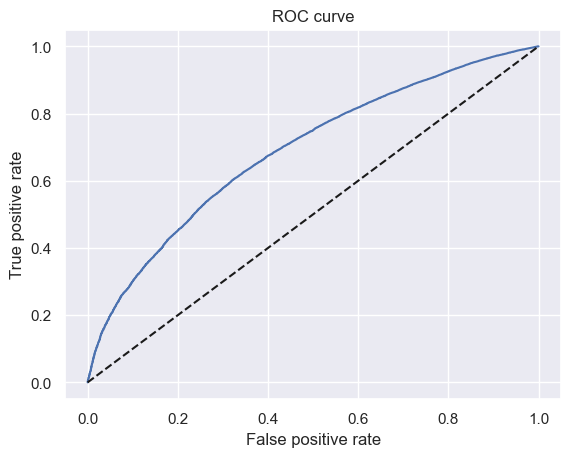

In [152]:
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [153]:
thresholds

array([       inf, 0.99094588, 0.98599267, ..., 0.50304594, 0.48345031,
       0.47120616], shape=(17994,))

In [154]:
thresholds.shape

(17994,)

In [155]:
df_cutoffs = pd.concat([pd.DataFrame(thresholds), pd.DataFrame(fpr), pd.DataFrame(tpr)], axis = 1)

In [156]:
df_cutoffs.columns = ['thresholds', 'fpr', 'tpr']

In [157]:
df_cutoffs.head()

,thresholds,fpr,tpr
0,inf,0.000000,0.000000
1,0.990946,0.000000,0.000012
2,0.985993,0.000000,0.000626
3,0.985986,0.000098,0.000626
4,0.984017,0.000098,0.002071


In [158]:
df_cutoffs['thresholds'][0] = 1 - 1 / np.power(10, 16)

C:\Users\aswin\AppData\Local\Temp\ipykernel_28852\3197044947.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cutoffs['thresholds'][0] = 1 - 1 / np.power(10, 16)


In [159]:
df_cutoffs['Score'] = ((np.log(df_cutoffs['thresholds'] / (1 - df_cutoffs['thresholds'])) - min_sum_coef) * ((max_score - min_score) / (max_sum_coef - min_sum_coef)) + min_score).round()

In [160]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,1.000000,0.000000,0.000000,3205.0
1,0.990946,0.000000,0.000012,770.0
2,0.985993,0.000000,0.000626,737.0
3,0.985986,0.000098,0.000626,737.0
4,0.984017,0.000098,0.002071,727.0


In [161]:
df_cutoffs['Score'][0] = max_score

C:\Users\aswin\AppData\Local\Temp\ipykernel_28852\3137964156.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cutoffs['Score'][0] = max_score


In [162]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score
0,1.000000,0.000000,0.000000,850.0
1,0.990946,0.000000,0.000012,770.0
2,0.985993,0.000000,0.000626,737.0
3,0.985986,0.000098,0.000626,737.0
4,0.984017,0.000098,0.002071,727.0


In [163]:
df_cutoffs.tail()

,thresholds,fpr,tpr,Score
17989,0.531434,0.999706,0.999952,423.0
17990,0.527905,0.999804,0.999952,422.0
17991,0.503046,0.999804,0.999988,414.0
17992,0.483450,1.000000,0.999988,409.0
17993,0.471206,1.000000,1.000000,405.0


In [164]:
def n_approved(p):
    return np.where(df_actual_predicted_probs['y_hat_test_proba'] >= p, 1, 0).sum()

In [165]:
df_cutoffs['N Approved'] = df_cutoffs['thresholds'].apply(n_approved)
df_cutoffs['N Rejected'] = df_actual_predicted_probs['y_hat_test_proba'].shape[0] - df_cutoffs['N Approved']
df_cutoffs['Approval Rate'] = df_cutoffs['N Approved'] / df_actual_predicted_probs['y_hat_test_proba'].shape[0]
df_cutoffs['Rejection Rate'] = 1 - df_cutoffs['Approval Rate']

In [166]:
df_cutoffs.head()

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
0,1.000000,0.000000,0.000000,850.0,0,93257,0.000000,1.000000
1,0.990946,0.000000,0.000012,770.0,1,93256,0.000011,0.999989
2,0.985993,0.000000,0.000626,737.0,52,93205,0.000558,0.999442
3,0.985986,0.000098,0.000626,737.0,53,93204,0.000568,0.999432
4,0.984017,0.000098,0.002071,727.0,173,93084,0.001855,0.998145


In [167]:
df_cutoffs.tail()

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
17989,0.531434,0.999706,0.999952,423.0,93250,7,0.999925,0.000075
17990,0.527905,0.999804,0.999952,422.0,93251,6,0.999936,0.000064
17991,0.503046,0.999804,0.999988,414.0,93254,3,0.999968,0.000032
17992,0.483450,1.000000,0.999988,409.0,93256,1,0.999989,0.000011
17993,0.471206,1.000000,1.000000,405.0,93257,0,1.000000,0.000000


In [168]:
df_cutoffs.iloc[5000: 6200, ]

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
5000,0.905277,0.246026,0.514958,585.0,45283,47974,0.485572,0.514428
5001,0.905273,0.246124,0.514958,585.0,45284,47973,0.485583,0.514417
5002,0.905258,0.246124,0.515042,585.0,45291,47966,0.485658,0.514342
5003,0.905256,0.246222,0.515042,585.0,45292,47965,0.485669,0.514331
5004,0.905234,0.246222,0.515138,585.0,45300,47957,0.485754,0.514246
5005,0.905233,0.246320,0.515138,585.0,45301,47956,0.485765,0.514235
5006,0.905194,0.246320,0.515451,585.0,45327,47930,0.486044,0.513956
5007,0.905193,0.246418,0.515451,585.0,45328,47929,0.486055,0.513945
5008,0.905186,0.246418,0.515560,585.0,45337,47920,0.486151,0.513849
5009,0.905185,0.246516,0.515560,585.0,45338,47919,0.486162,0.513838


In [169]:
df_cutoffs.iloc[1000: 2000, ]

,thresholds,fpr,tpr,Score,N Approved,N Rejected,Approval Rate,Rejection Rate
1000,0.953637,0.043572,0.181576,643.0,15527,77730,0.166497,0.833503
1001,0.953608,0.043572,0.181781,643.0,15544,77713,0.166679,0.833321
1002,0.953606,0.043670,0.181781,643.0,15545,77712,0.166690,0.833310
1003,0.953599,0.043670,0.181865,643.0,15552,77705,0.166765,0.833235
1004,0.953595,0.043768,0.181865,643.0,15553,77704,0.166776,0.833224
1005,0.953570,0.043768,0.182082,643.0,15571,77686,0.166969,0.833031
1006,0.953568,0.043867,0.182082,643.0,15572,77685,0.166979,0.833021
1007,0.953541,0.043867,0.182166,643.0,15579,77678,0.167054,0.832946
1008,0.953539,0.043965,0.182166,643.0,15580,77677,0.167065,0.832935
1009,0.953492,0.043965,0.182407,643.0,15600,77657,0.167280,0.832720


In [170]:
inputs_train_with_ref_cat.to_csv('inputs_train_with_ref_cat.csv')

In [171]:
df_scorecard.to_csv('df_scorecard.csv')